# MPA-MLF Final Project: Room Occupancy Classification (v3 — adapted to actual dataset)

Adapted to the real file layout:
- Images directly in `./x_train/` and `./x_test/` with names `img_<N>.png`
- CSVs: `y_train_v2.csv` and `y_test_submission_example_v2.csv`, columns `id,target`
- File ↔ CSV mapping: CSV `id=N` ↔ `img_{N+1}.png` (images are 1-indexed, labels are 0-indexed)

## 1. Setup & Imports

In [1]:
import os, math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.16.2
GPU available: True


## 2. Configuration — paths match the actual project folder

In [2]:
# Project root = current working directory where the notebook lives
ROOT = Path('.').resolve()

TRAIN_IMG_DIR = ROOT / 'x_train'
TEST_IMG_DIR  = ROOT / 'x_test'
Y_TRAIN_CSV   = ROOT / 'y_train_v2.csv'
SUBMISSION_EXAMPLE = ROOT / 'y_test_submission_example_v2.csv'

OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Hyperparameters ---
IMG_SIZE        = 96
BATCH_SIZE      = 64
EPOCHS          = 120
NUM_CLASSES     = 4
LEARNING_RATE   = 2e-3
WARMUP_EPOCHS   = 5
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA     = 0.2
NUM_FOLDS       = 5
VAL_SPLIT       = 0.15
RUN_KFOLD       = True    # <- set False for a quick single-model run

# Sanity checks
assert TRAIN_IMG_DIR.exists(), f'Missing {TRAIN_IMG_DIR}'
assert TEST_IMG_DIR.exists(),  f'Missing {TEST_IMG_DIR}'
assert Y_TRAIN_CSV.exists(),   f'Missing {Y_TRAIN_CSV}'
print('Paths OK.')
print(f'  train images: {len(list(TRAIN_IMG_DIR.glob("*.png")))}')
print(f'  test  images: {len(list(TEST_IMG_DIR.glob("*.png")))}')

Paths OK.
  train images: 9227
  test  images: 3955


## 3. Load Labels

In [3]:
y_train_df = pd.read_csv(Y_TRAIN_CSV)
print('Columns:', y_train_df.columns.tolist())
print('Shape  :', y_train_df.shape)
y_train_df.head()

Columns: ['id', 'target']
Shape  : (9227, 2)


,id,target
0,0,0
1,1,1
2,2,0
3,3,2
4,4,2


Class distribution:
target
0    1462
1    3786
2    3002
3     977
Name: count, dtype: int64


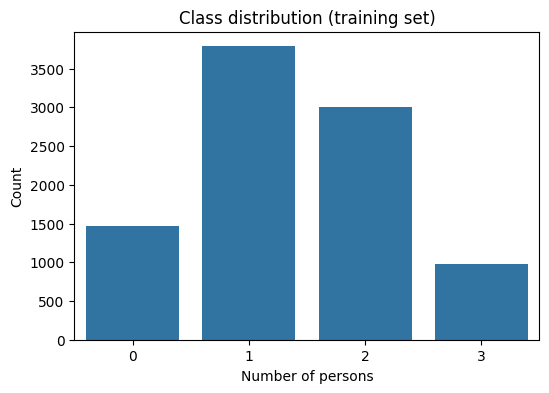

In [4]:
ID_COL, LABEL_COL = 'id', 'target'

class_counts = y_train_df[LABEL_COL].value_counts().sort_index()
print('Class distribution:')
print(class_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values)
plt.title('Class distribution (training set)')
plt.xlabel('Number of persons'); plt.ylabel('Count')
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Load Images into Numpy Arrays

Filename convention: CSV `id=N` ↔ file `img_{N+1}.png` (images are 1-indexed, labels 0-indexed).

In [5]:
def load_image(path, size=IMG_SIZE):
    img = Image.open(path).convert('L')
    img = img.resize((size, size), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0

def build_filename(sample_id):
    # CSV ids are 0-indexed, PNG filenames are 1-indexed -> +1
    return f'img_{int(sample_id) + 1}.png'

# --- Training data ---
X_train_list, y_train_list = [], []
missing = 0
for _, row in tqdm(y_train_df.iterrows(), total=len(y_train_df), desc='Loading train'):
    fpath = TRAIN_IMG_DIR / build_filename(row[ID_COL])
    if not fpath.exists():
        missing += 1
        continue
    X_train_list.append(load_image(fpath))
    y_train_list.append(int(row[LABEL_COL]))

X = np.expand_dims(np.stack(X_train_list), -1)
y = np.array(y_train_list, dtype=np.int32)
print(f'X shape: {X.shape}, y shape: {y.shape}, missing files: {missing}')
assert missing == 0, 'Some training images were missing — check the filename mapping.'

Loading train: 100%|██████████| 9227/9227 [00:05<00:00, 1654.92it/s]


X shape: (9227, 96, 96, 1), y shape: (9227,), missing files: 0


In [6]:
# --- Test data ---
sub_example = pd.read_csv(SUBMISSION_EXAMPLE)
print('Submission example columns:', sub_example.columns.tolist())
test_ids = sub_example['id'].tolist()

X_test_list = []
missing_test = 0
for tid in tqdm(test_ids, desc='Loading test'):
    fpath = TEST_IMG_DIR / build_filename(tid)
    if not fpath.exists():
        missing_test += 1
        continue
    X_test_list.append(load_image(fpath))

X_test = np.expand_dims(np.stack(X_test_list), -1)
print(f'X_test shape: {X_test.shape}, missing: {missing_test}')
assert missing_test == 0, 'Some test images were missing.'

Submission example columns: ['id', 'target']


Loading test: 100%|██████████| 3955/3955 [00:02<00:00, 1794.75it/s]

X_test shape: (3955, 96, 96, 1), missing: 0


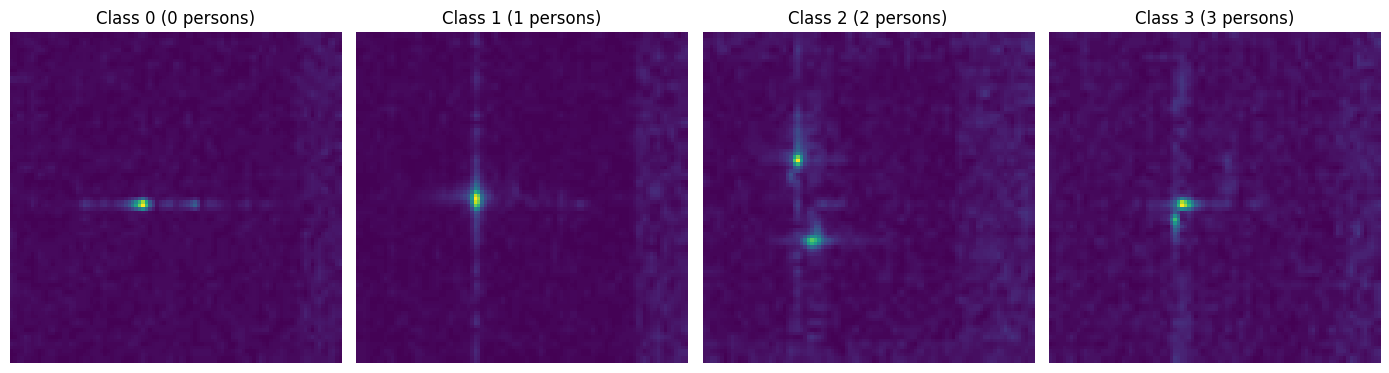

In [7]:
# Peek at a few images, one per class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14,4))
for c in range(NUM_CLASSES):
    ids_c = y_train_df[y_train_df[LABEL_COL] == c][ID_COL].values
    axes[c].imshow(X[ids_c[0]].squeeze(), cmap='viridis')
    axes[c].set_title(f'Class {c} ({c} persons)')
    axes[c].axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. MixUp Data Generator

In [8]:
def mixup_batch(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0: return x, y
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1.0 - lam)
    idx = np.random.permutation(x.shape[0])
    x_mix = lam * x + (1 - lam) * x[idx]
    y_mix = lam * y + (1 - lam) * y[idx]
    return x_mix.astype(np.float32), y_mix.astype(np.float32)

class MixUpSequence(keras.utils.Sequence):
    def __init__(self, X, y_cat, batch_size, alpha=MIXUP_ALPHA, shuffle=True):
        self.X, self.y = X, y_cat
        self.bs, self.alpha, self.shuffle = batch_size, alpha, shuffle
        self.idx = np.arange(len(X))
        self.on_epoch_end()
    def __len__(self): return math.ceil(len(self.X) / self.bs)
    def __getitem__(self, i):
        b = self.idx[i*self.bs:(i+1)*self.bs]
        return mixup_batch(self.X[b], self.y[b], self.alpha)
    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.idx)

## 6. Model Architecture (Residual + SE blocks)

In [9]:
def se_block(x, ratio=8):
    ch = x.shape[-1]
    s = layers.GlobalAveragePooling2D()(x)
    s = layers.Dense(max(ch // ratio, 4), activation='relu')(s)
    s = layers.Dense(ch, activation='sigmoid')(s)
    s = layers.Reshape((1, 1, ch))(s)
    return layers.Multiply()([x, s])

def res_block(x, filters, reg):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=reg, use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=reg, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = se_block(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    return layers.Activation('relu')(x)

def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES, l2=1e-4):
    reg = regularizers.l2(l2)
    inputs = keras.Input(shape=input_shape)
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomTranslation(0.06, 0.06, fill_mode='constant')(x)
    x = layers.RandomZoom(0.08)(x)
    x = layers.GaussianNoise(0.02)(x)
    x = layers.Conv2D(48, 5, padding='same', kernel_regularizer=reg, use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = res_block(x, 64, reg)
    x = res_block(x, 64, reg)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    x = res_block(x, 128, reg)
    x = res_block(x, 128, reg)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)
    x = res_block(x, 192, reg)
    x = res_block(x, 192, reg)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='RoomOccupancyCNN_v3')

build_cnn().summary()

2026-04-24 19:15:21.154127: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-24 19:15:21.154307: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-24 19:15:21.154352: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-24 19:15:21.154444: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-24 19:15:21.154497: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "RoomOccupancyCNN_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 96, 96, 1) │          0 │ input_layer[0][0] │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation  │ (None, 96, 96, 1) │          0 │ random_flip[0][0] │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 96, 96, 1) │          0 │ random_translati… │
│ (RandomZoom)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 96, 96, 1) │          0 │ random_zoom[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │      1,200 │ gaussian_noise[0… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 96,    │        192 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 48,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 48,    │     27,648 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 48, 48,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        520 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        576 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,971,028 (7.52 MB)

 Trainable params: 1,966,836 (7.50 MB)

 Non-trainable params: 4,192 (16.38 KB)

## 7. Cosine LR schedule + warmup

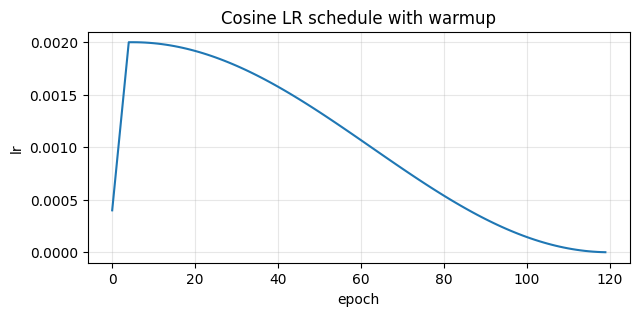

In [10]:
def cosine_warmup(epoch, total_epochs=EPOCHS, warmup=WARMUP_EPOCHS, base_lr=LEARNING_RATE, min_lr=1e-6):
    if epoch < warmup:
        return base_lr * (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, total_epochs - warmup)
    return min_lr + (base_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

lrs = [cosine_warmup(e) for e in range(EPOCHS)]
plt.figure(figsize=(7,3)); plt.plot(lrs); plt.grid(alpha=0.3)
plt.title('Cosine LR schedule with warmup'); plt.xlabel('epoch'); plt.ylabel('lr')
plt.show()

## 8. Train single model

In [11]:
def make_optimizer():
    try:
        return keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    except Exception:
        return keras.optimizers.Adam(LEARNING_RATE)

def make_loss():
    return keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=VAL_SPLIT, stratify=y, random_state=SEED
)
y_tr_cat  = to_categorical(y_tr,  NUM_CLASSES)
y_val_cat = to_categorical(y_val, NUM_CLASSES)
print(f'Train: {X_tr.shape}, Val: {X_val.shape}')

model = build_cnn()
model.compile(optimizer=make_optimizer(), loss=make_loss(), metrics=['accuracy'])

train_gen = MixUpSequence(X_tr, y_tr_cat, BATCH_SIZE, alpha=MIXUP_ALPHA)

cb = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True, verbose=1),
    callbacks.LearningRateScheduler(lambda e: cosine_warmup(e)),
    callbacks.ModelCheckpoint(str(OUTPUT_DIR / 'best_model.keras'),
                              monitor='val_accuracy', save_best_only=True, verbose=0),
]

history = model.fit(
    train_gen,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    callbacks=cb,
    verbose=2
)

Train: (7842, 96, 96, 1), Val: (1385, 96, 96, 1)
Epoch 1/120


/Users/vishal/Documents/Brno/Machine Learning Fundamentals/Projet/.venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2026-04-24 19:15:46.350123: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


123/123 - 197s - 2s/step - accuracy: 0.3653 - loss: 1.6180 - val_accuracy: 0.3249 - val_loss: 1.4996 - learning_rate: 4.0000e-04
Epoch 2/120
123/123 - 115s - 934ms/step - accuracy: 0.4685 - loss: 1.4411 - val_accuracy: 0.1581 - val_loss: 3.6814 - learning_rate: 8.0000e-04
Epoch 3/120
123/123 - 122s - 993ms/step - accuracy: 0.5231 - loss: 1.3142 - val_accuracy: 0.1755 - val_loss: 4.2244 - learning_rate: 0.0012
Epoch 4/120
123/123 - 128s - 1s/step - accuracy: 0.5695 - loss: 1.2427 - val_accuracy: 0.2123 - val_loss: 2.1103 - learning_rate: 0.0016
Epoch 5/120
123/123 - 119s - 966ms/step - accuracy: 0.6030 - loss: 1.1842 - val_accuracy: 0.3264 - val_loss: 1.5018 - learning_rate: 0.0020
Epoch 6/120
123/123 - 109s - 886ms/step - accuracy: 0.6345 - loss: 1.1258 - val_accuracy: 0.5199 - val_loss: 1.2584 - learning_rate: 0.0020
Epoch 7/120
123/123 - 122s - 991ms/step - accuracy: 0.6656 - loss: 1.0749 - val_accuracy: 0.5978 - val_loss: 1.1251 - learning_rate: 0.0020
Epoch 8/120
123/123 - 127s - 1

KeyboardInterrupt: 

## 9. Training curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. TTA + Validation evaluation

In [ ]:
def strong_tta(model, X, n_noise=6, batch_size=BATCH_SIZE):
    preds = [model.predict(X, batch_size=batch_size, verbose=0)]
    X_flip = X[:, :, ::-1, :]
    preds.append(model.predict(X_flip, batch_size=batch_size, verbose=0))
    for i in range(n_noise):
        base = X if i % 2 == 0 else X_flip
        scale = 0.015 + 0.015 * np.random.rand()
        noise = np.random.normal(0, scale, size=X.shape).astype(np.float32)
        preds.append(model.predict(np.clip(base + noise, 0, 1), batch_size=batch_size, verbose=0))
    return np.mean(preds, axis=0)

In [ ]:
val_pred_plain = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0)
val_pred_tta   = strong_tta(model, X_val, n_noise=6)
print(f'Val accuracy (no TTA): {accuracy_score(y_val, np.argmax(val_pred_plain, axis=1)):.4f}')
print(f'Val accuracy (TTA)  : {accuracy_score(y_val, np.argmax(val_pred_tta,   axis=1)):.4f}')

print()
print(classification_report(y_val, np.argmax(val_pred_tta, axis=1),
                            target_names=[f'{i} persons' for i in range(NUM_CLASSES)]))

cm = confusion_matrix(y_val, np.argmax(val_pred_tta, axis=1))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES))
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion matrix (val, TTA)')
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 5-fold stratified ensemble

In [ ]:
if RUN_KFOLD:
    skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
    test_preds_sum = np.zeros((X_test.shape[0], NUM_CLASSES))
    oof_preds      = np.zeros((X.shape[0], NUM_CLASSES))
    fold_val_accs  = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        print(f'\n===== Fold {fold}/{NUM_FOLDS} =====')
        X_tr_f, X_va_f = X[tr_idx], X[va_idx]
        y_tr_f = to_categorical(y[tr_idx], NUM_CLASSES)
        y_va_f = to_categorical(y[va_idx], NUM_CLASSES)
        m = build_cnn()
        m.compile(optimizer=make_optimizer(), loss=make_loss(), metrics=['accuracy'])
        fcb = [
            callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, verbose=0),
            callbacks.LearningRateScheduler(lambda e: cosine_warmup(e)),
        ]
        m.fit(
            MixUpSequence(X_tr_f, y_tr_f, BATCH_SIZE, alpha=MIXUP_ALPHA),
            validation_data=(X_va_f, y_va_f),
            epochs=EPOCHS, callbacks=fcb, verbose=2
        )
        oof_preds[va_idx] = strong_tta(m, X_va_f, n_noise=4)
        fold_acc = accuracy_score(y[va_idx], np.argmax(oof_preds[va_idx], axis=1))
        fold_val_accs.append(fold_acc)
        print(f'Fold {fold} val accuracy (TTA): {fold_acc:.4f}')
        test_preds_sum += strong_tta(m, X_test, n_noise=6)
        m.save(str(OUTPUT_DIR / f'model_fold{fold}.keras'))
        keras.backend.clear_session()

    test_preds_avg = test_preds_sum / NUM_FOLDS
    oof_cls = np.argmax(oof_preds, axis=1)
    print(f'\n===== ENSEMBLE RESULTS =====')
    print(f'Per-fold val accs (TTA): {[f"{a:.4f}" for a in fold_val_accs]}')
    print(f'Mean fold acc          : {np.mean(fold_val_accs):.4f}')
    print(f'OOF ensemble accuracy  : {accuracy_score(y, oof_cls):.4f}')
else:
    test_preds_avg = strong_tta(model, X_test, n_noise=6)
    print('K-fold skipped. Using single-model TTA predictions.')

## 12. Build Kaggle submission

In [ ]:
test_cls = np.argmax(test_preds_avg, axis=1)

sub = pd.read_csv(SUBMISSION_EXAMPLE)
# Expected columns: id,target
sub['target'] = test_cls

submission_path = OUTPUT_DIR / 'submission.csv'
sub.to_csv(submission_path, index=False)
print(f'Submission saved to: {submission_path}')
print(sub.head())
print('\nPredicted class distribution:')
print(pd.Series(test_cls).value_counts().sort_index())